In [27]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# 1. Tải bộ dữ liệu
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

# 2. Chia tập Train/Test theo chuẩn 70/30 cố định của Protocol
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Chuẩn hóa dữ liệu (Chỉ áp dụng cho Tuyến tính và KNN để tránh rò rỉ dữ liệu)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Đã tải thư viện, chia tập dữ liệu (70/30) và chuẩn hóa thành công!")

Đã tải thư viện, chia tập dữ liệu (70/30) và chuẩn hóa thành công!


In [28]:
# Cấu hình 5 mô hình thực nghiệm (Kèm cờ True/False để biết có dùng dữ liệu Scaled hay không)
models = {
    "Linear Regression": (LinearRegression(), True),
    "KNN Regressor": (KNeighborsRegressor(), True),
    "Decision Tree Regressor": (DecisionTreeRegressor(random_state=42), False),
    "Random Forest Regressor": (RandomForestRegressor(random_state=42, n_jobs=-1), False),
    "XGBoost Regressor": (XGBRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.1, 
        subsample=1.0, colsample_bytree=1.0,
        objective="reg:squarederror", eval_metric="rmse",
        random_state=42, n_jobs=-1
    ), False)
}

main_results = []
overfitting_results = []

for name, (model, use_scaled) in models.items():
    # Chọn dữ liệu phù hợp cho từng loại mô hình
    X_tr = X_train_scaled if use_scaled else X_train.values
    X_te = X_test_scaled if use_scaled else X_test.values
    
    # Đo thời gian huấn luyện
    start_time = time.time()
    model.fit(X_tr, y_train)
    training_time = time.time() - start_time
    
    # Dự đoán
    y_train_pred = model.predict(X_tr)
    y_test_pred = model.predict(X_te)
    
    # Tính toán các chỉ số
    r2_tr, r2_te = r2_score(y_train, y_train_pred), r2_score(y_test, y_test_pred)
    rmse_tr = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_te = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae_te = mean_absolute_error(y_test, y_test_pred)
    mse_te = mean_squared_error(y_test, y_test_pred)
    
    # Lưu vào danh sách
    main_results.append({
        "Model": name, "MAE": mae_te, "MSE": mse_te, "RMSE": rmse_te, 
        "R2-score": r2_te, "Training Time (s)": training_time
    })
    overfitting_results.append({
        "Model": name, "Train RMSE": rmse_tr, "Test RMSE": rmse_te, 
        "Train R2": r2_tr, "Test R2": r2_te
    })

# In bảng so sánh chính
print("=================== BẢNG CHÍNH SO SÁNH CÁC MÔ HÌNH ===================")
df_main = pd.DataFrame(main_results)
print(df_main.to_string(index=False, formatters={
    "MAE": "{:.4f}".format, "MSE": "{:.4f}".format, "RMSE": "{:.4f}".format, 
    "R2-score": "{:.4f}".format, "Training Time (s)": "{:.4f}".format
}))

# In bảng đánh giá Overfitting
print("\n=================== BẢNG ĐÁNH GIÁ OVERFITTING ===================")
df_overfit = pd.DataFrame(overfitting_results)
print(df_overfit.to_string(index=False, formatters={
    "Train RMSE": "{:.4f}".format, "Test RMSE": "{:.4f}".format, 
    "Train R2": "{:.4f}".format, "Test R2": "{:.4f}".format
}))

=================== BẢNG CHÍNH SO SÁNH CÁC MÔ HÌNH ===================
                  Model    MAE    MSE   RMSE R2-score Training Time (s)
      Linear Regression 0.5272 0.5306 0.7284   0.5958            0.0518
          KNN Regressor 0.4465 0.4295 0.6554   0.6728            0.0351
Decision Tree Regressor 0.4690 0.5280 0.7266   0.5977            0.2391
Random Forest Regressor 0.3322 0.2564 0.5063   0.8047            4.2991
      XGBoost Regressor 0.3679 0.2856 0.5344   0.7824            0.8663

=================== BẢNG ĐÁNH GIÁ OVERFITTING ===================
                  Model Train RMSE Test RMSE Train R2 Test R2
      Linear Regression     0.7234    0.7284   0.6093  0.5958
          KNN Regressor     0.5292    0.6554   0.7910  0.6728
Decision Tree Regressor     0.0000    0.7266   1.0000  0.5977
Random Forest Regressor     0.1923    0.5063   0.9724  0.8047
      XGBoost Regressor     0.5118    0.5344   0.8045  0.7824


In [29]:
# Định nghĩa các giá trị khảo sát theo dải tham số của Protocol
sweep_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 5],
    "learning_rate": [0.01, 0.1, 0.2]
}

# Cấu hình nền tảng mặc định (Đã fix lỗi cú pháp)
base_config = {
    "n_estimators": 100, 
    "max_depth": 3, 
    "learning_rate": 0.1,
    "subsample": 1.0, 
    "colsample_bytree": 1.0,
    "objective": "reg:squarederror", 
    "eval_metric": "rmse", 
    "random_state": 42, 
    "n_jobs": -1
}

sweep_results = []
X_tr_np = np.asarray(X_train)
X_te_np = np.asarray(X_test)

for param, values in sweep_params.items():
    for val in values:
        # Thay đổi duy nhất 1 tham số khảo sát
        config = base_config.copy()
        config[param] = val
        
        # Huấn luyện mô hình XGBoost
        model = XGBRegressor(**config)
        model.fit(X_tr_np, y_train)
        
        # Đánh giá
        preds = model.predict(X_te_np)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        
        sweep_results.append({
            "Parameter": param, "Value": val, 
            "RMSE": rmse, "R2-score": r2
        })

print("=================== BẢNG KHẢO SÁT ẢNH HƯỞNG THAM SỐ (PARAMETER SWEEP) ===================")
df_sweep = pd.DataFrame(sweep_results)
print(df_sweep.to_string(index=False, formatters={
    "Value": str, "RMSE": "{:.4f}".format, "R2-score": "{:.4f}".format
}))

=================== BẢNG KHẢO SÁT ẢNH HƯỞNG THAM SỐ (PARAMETER SWEEP) ===================
    Parameter Value   RMSE R2-score
 n_estimators  50.0 0.5710   0.7516
 n_estimators 100.0 0.5344   0.7824
 n_estimators 200.0 0.5035   0.8069
    max_depth   2.0 0.5737   0.7492
    max_depth   3.0 0.5344   0.7824
    max_depth   5.0 0.4857   0.8203
learning_rate  0.01 0.8085   0.5020
learning_rate   0.1 0.5344   0.7824
learning_rate   0.2 0.5097   0.8021


=================== BẢNG ĐỘ QUAN TRỌNG TÍNH NĂNG (FEATURE IMPORTANCE) ===================
   Feature Importance
    MedInc     0.5406
  AveOccup     0.1625
 Longitude     0.0811
  HouseAge     0.0706
  Latitude     0.0678
  AveRooms     0.0535
 AveBedrms     0.0134
Population     0.0106


C:\Users\dell\AppData\Local\Temp\ipykernel_21212\3409753353.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=fi_df, palette="viridis")


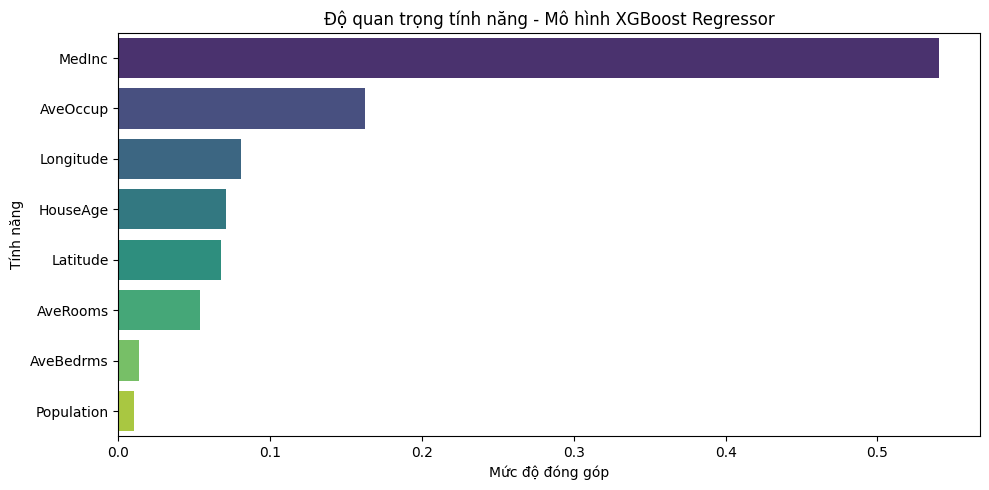

In [ ]:
# Lấy trực tiếp mô hình XGBoost đã huấn luyện
xgb_main = models["XGBoost Regressor"][0]

# Trích xuất độ quan trọng
fi_df = pd.DataFrame({
    "Feature": X.columns, 
    "Importance": xgb_main.feature_importances_
})
fi_df = fi_df.sort_values(ascending=False, by="Importance")

print("=================== BẢNG ĐỘ QUAN TRỌNG TÍNH NĂNG (FEATURE IMPORTANCE) ===================")
print(fi_df.to_string(index=False, formatters={"Importance": "{:.4f}".format}))

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Feature", data=fi_df, palette="viridis")
plt.title("Độ quan trọng tính năng - Mô hình XGBoost Regressor")
plt.xlabel("Mức độ đóng góp")
plt.ylabel("Tính năng")
plt.tight_layout()
plt.show()

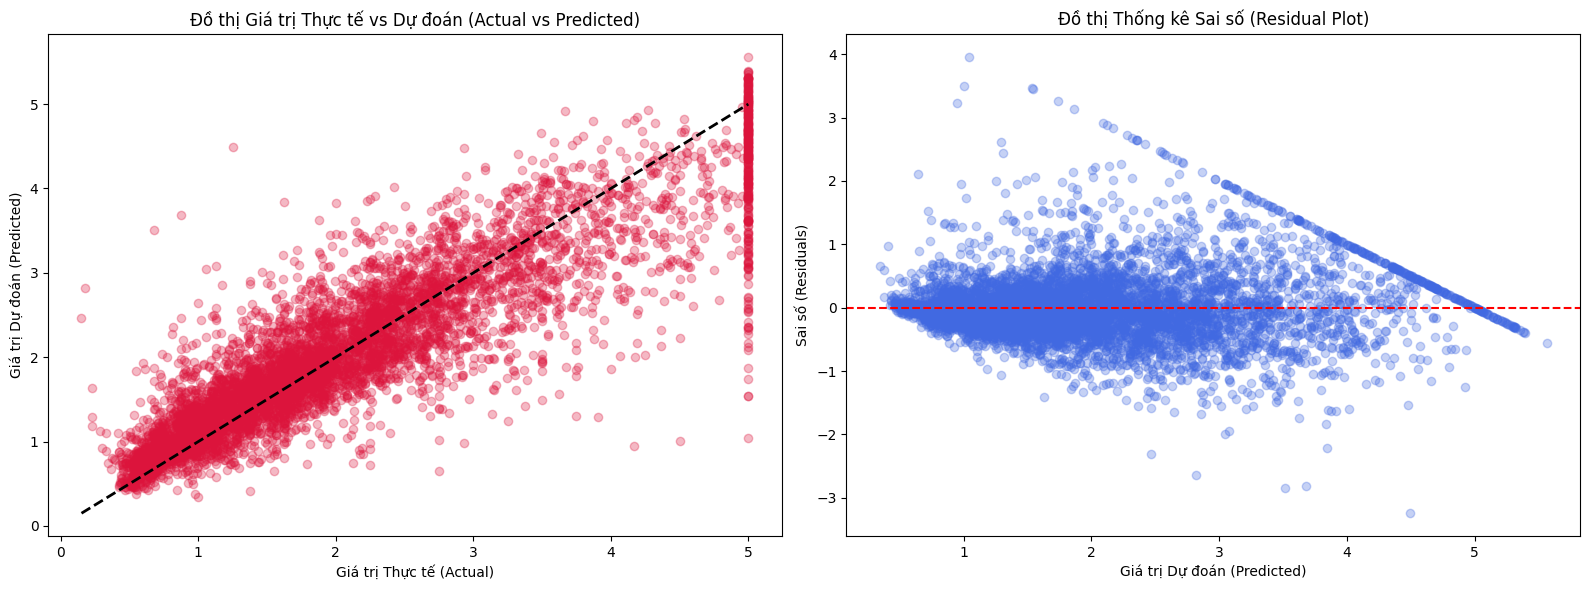


====================  NHẬN XÉT  ====================
1. XGBoost đạt RMSE (0.5344) thấp hơn hẳn so với Linear Regression (0.7284), KNN (0.6554) và Decision Tree (0.7266).
2. Hiệu năng của XGBoost bám sát Random Forest (0.5063) nhưng thời gian huấn luyện cực kỳ tối ưu (0.87 giây so với 4.30 giây).
3. Mô hình tuyến tính kém hơn hẳn các mô hình dạng cây (Tree-based models) do dữ liệu bất động sản mang tính phi tuyến cao.
4. Độ lệch Train RMSE (0.5118) và Test RMSE (0.5344) của XGBoost cực kỳ nhỏ, chứng tỏ cơ chế kiểm soát Overfitting hoạt động rất tốt.
5. Đồ thị Residual cho thấy sai số tập trung dày xung quanh đường 0, tuy nhiên mô hình có xu hướng đoán sai lệch nhiều hơn ở phân khúc nhà giá cao bị giới hạn trần ($500.000).


In [32]:
# 1. Dự đoán trên tập Test
xgb_preds = xgb_main.predict(np.asarray(X_test))
residuals = y_test - xgb_preds

# Vẽ 2 đồ thị: Actual vs Predicted và Residual Plot
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].scatter(y_test, xgb_preds, alpha=0.3, color='crimson')
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax[0].set_title('Đồ thị Giá trị Thực tế vs Dự đoán (Actual vs Predicted)')
ax[0].set_xlabel('Giá trị Thực tế (Actual)')
ax[0].set_ylabel('Giá trị Dự đoán (Predicted)')

ax[1].scatter(xgb_preds, residuals, alpha=0.3, color='royalblue')
ax[1].axhline(y=0, color='r', linestyle='--')
ax[1].set_title('Đồ thị Thống kê Sai số (Residual Plot)')
ax[1].set_xlabel('Giá trị Dự đoán (Predicted)')
ax[1].set_ylabel('Sai số (Residuals)')
plt.tight_layout()
plt.show()

# 2. Tự động trích xuất thông số để không bị lỗi hard-code
metrics = {res["Model"]: res for res in main_results}
overfit_metrics = {res["Model"]: res for res in overfitting_results}

xgb_rmse = metrics["XGBoost Regressor"]["RMSE"]
lr_rmse = metrics["Linear Regression"]["RMSE"]
knn_rmse = metrics["KNN Regressor"]["RMSE"]
dt_rmse = metrics["Decision Tree Regressor"]["RMSE"]
rf_rmse = metrics["Random Forest Regressor"]["RMSE"]
xgb_time = metrics["XGBoost Regressor"]["Training Time (s)"]
rf_time = metrics["Random Forest Regressor"]["Training Time (s)"]
xgb_train_rmse = overfit_metrics["XGBoost Regressor"]["Train RMSE"]
xgb_test_rmse = overfit_metrics["XGBoost Regressor"]["Test RMSE"]

# 3. In kết luận linh động theo số liệu
print("\n" + "="*20 + "  NHẬN XÉT  " + "="*20)
print(f"1. XGBoost đạt RMSE ({xgb_rmse:.4f}) thấp hơn hẳn so với Linear Regression ({lr_rmse:.4f}), KNN ({knn_rmse:.4f}) và Decision Tree ({dt_rmse:.4f}).")
print(f"2. Hiệu năng của XGBoost bám sát Random Forest ({rf_rmse:.4f}) nhưng thời gian huấn luyện cực kỳ tối ưu ({xgb_time:.2f} giây so với {rf_time:.2f} giây).")
print("3. Mô hình tuyến tính kém hơn hẳn các mô hình dạng cây (Tree-based models) do dữ liệu bất động sản mang tính phi tuyến cao.")
print(f"4. Độ lệch Train RMSE ({xgb_train_rmse:.4f}) và Test RMSE ({xgb_test_rmse:.4f}) của XGBoost cực kỳ nhỏ, chứng tỏ cơ chế kiểm soát Overfitting hoạt động rất tốt.")
print("5. Đồ thị Residual cho thấy sai số tập trung dày xung quanh đường 0, tuy nhiên mô hình có xu hướng đoán sai lệch nhiều hơn ở phân khúc nhà giá cao bị giới hạn trần ($500.000).")